# Imports

In [31]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"
import warnings
warnings.filterwarnings('ignore')
from scipy import optimize, interpolate
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error
import copy
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.linear_model import LinearRegression
import random

# Gather Data

In [32]:
Data_dir = "Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))

## Plot the Data

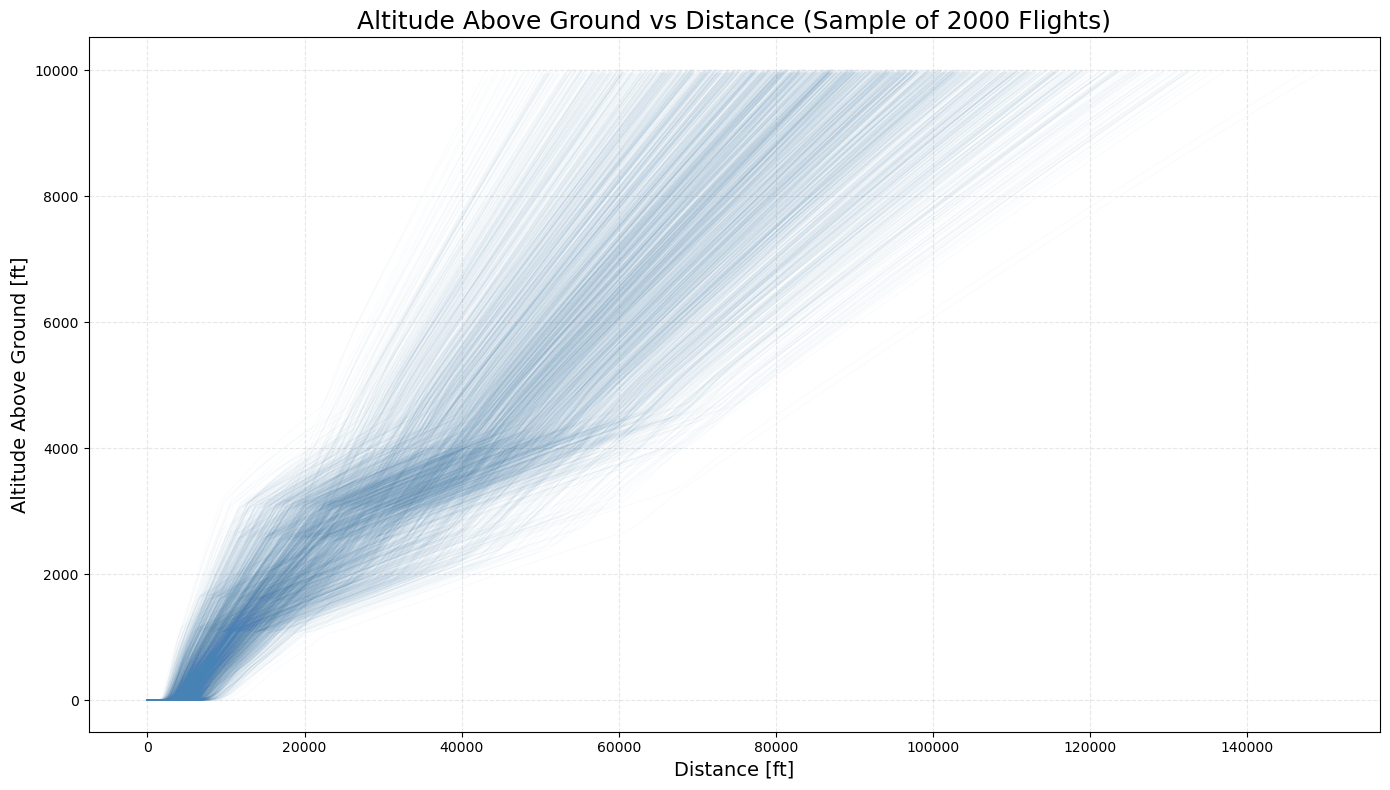

In [33]:
plt.figure(figsize=(14, 8))

for f in f_lst[:2000]:
    df = pd.read_csv(f)
    plt.plot(
        df["Distance"],
        df["Altitude_Above_Ground"],
        color="steelblue",
        linewidth=0.8,
        alpha=0.03
    )

plt.title("Altitude Above Ground vs Distance (Sample of 2000 Flights)", fontsize=18)
plt.xlabel("Distance [ft]", fontsize=14)
plt.ylabel("Altitude Above Ground [ft]", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Save the figure (high resolution)
plt.savefig("altitude_distance_plot.png", dpi=300)

plt.show()

## Weight Model Data

In [34]:
desired_columns = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2", "Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3", "acc_max", "Total_Weight"]

In [5]:
weight_min = 110000
weight_max = 174000
cutoff_weight_top = 0.75
cutoff_weight_bot = 0.25
throttle_top_max = 1.0
throttle_bot_max = 0.97
throttle_top_min = 0.935
throttle_bot_min = 0.89
counter = 0
null_counter = 0
i = 0
Data_Weight = pd.DataFrame(columns = desired_columns + ["ID"])
f_lst_bad = []
weight_lst = []
throttle_lst = []
for f in f_lst[:]:
    if np.mod(counter, 100)==0:
        print("counter = ", counter)
    counter+=1
    df = pd.read_csv(f)

    # Get the good slice of data for weight model
    t0 = df[df["Segment"]=="Take_Off"].iloc[-1]["Throttle"]
    weight_0 = df.iloc[0]["Total_Weight"]
    weight_ratio = (weight_0-weight_min)/(weight_max-weight_min)
    if weight_ratio>cutoff_weight_top:
        throttle_top = copy.copy(throttle_top_max)
    else:
        throttle_top = throttle_top_min + (throttle_top_max-throttle_top_min)/cutoff_weight_top*weight_ratio
    
    if weight_ratio<cutoff_weight_bot:
        throttle_bot = copy.copy(throttle_bot_min)
    else:
        throttle_bot = throttle_bot_min + (throttle_bot_max-throttle_bot_min)/(1-cutoff_weight_bot)*(weight_ratio-cutoff_weight_bot)

    if (t0<throttle_bot) or (t0>throttle_top):
        null_counter += 1
        f_lst_bad.append(f)
        continue
    data_temp = df[(df["Throttle"]==t0)&(df["Segment"]=="Slow_Climb")]
    tolerance = 3
    stability_window = 5
    stability_threshold = 3
    data_temp["near_command"] = (data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).mean().sub(df.iloc[0]["Climb_CAS"]).abs() < tolerance)
    data_temp["cas_std"] = data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).std()
    data_temp["stable"] = data_temp["cas_std"] < stability_threshold
    data_temp["good"] = data_temp["near_command"] & data_temp["stable"]
    data_temp["slice"] = (data_temp["good"] != data_temp["good"].shift()).cumsum()
    slices = data_temp[data_temp["good"]].groupby("slice")
    if np.sum(data_temp["good"])==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    longest_slice_id = slices.size().idxmax()
    longest_slice = data_temp[data_temp["slice"] == longest_slice_id].copy()
    if len(longest_slice)==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    else:
        weight_lst.append(weight_0)
        throttle_lst.append(t0)
        Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = longest_slice[["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        # Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = df[(df["Altitude_Above_Ground"]>600) & (df["Altitude_Above_Ground"]<800)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3"]] = df[(df["Altitude_Above_Ground"]>9000) & (df["Altitude_Above_Ground"]<10100)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2"]] = df[df["Segment"]=="Acceleration"].iloc[-10:][["Acceleration", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, "Total_Weight"] = df["Total_Weight"].mean()
        Data_Weight.loc[i, "Climb_CAS"] = df.loc[0, "Climb_CAS"]
        Data_Weight.loc[i, "ID"] = f
        Data_Weight.loc[i, "Thrust_Max"] = np.max(df["Thrust"])
        df_acc = df[(df["Ground_Speed"]>5) & (df["Ground_Speed"]<15)]
        Data_Weight.loc[i, "acc_max"] = (df_acc.iloc[-1]["Ground_Speed"]-df_acc.iloc[0]["Ground_Speed"])/(df_acc.iloc[-1]["Time"]-df_acc.iloc[0]["Time"])
        i+=1

counter =  0
counter =  100
counter =  200
counter =  300
counter =  400
counter =  500
counter =  600
counter =  700
counter =  800
counter =  900
counter =  1000
counter =  1100
counter =  1200
counter =  1300
counter =  1400
counter =  1500
counter =  1600
counter =  1700
counter =  1800
counter =  1900
counter =  2000
counter =  2100
counter =  2200
counter =  2300
counter =  2400
counter =  2500
counter =  2600
counter =  2700
counter =  2800
counter =  2900
counter =  3000
counter =  3100
counter =  3200
counter =  3300
counter =  3400
counter =  3500
counter =  3600
counter =  3700
counter =  3800
counter =  3900
counter =  4000
counter =  4100
counter =  4200
counter =  4300
counter =  4400
counter =  4500
counter =  4600
counter =  4700
counter =  4800
counter =  4900
counter =  5000
counter =  5100
counter =  5200
counter =  5300
counter =  5400
counter =  5500
counter =  5600
counter =  5700
counter =  5800
counter =  5900
counter =  6000
counter =  6100
counter =  6200
coun

In [35]:
null_counter

5667

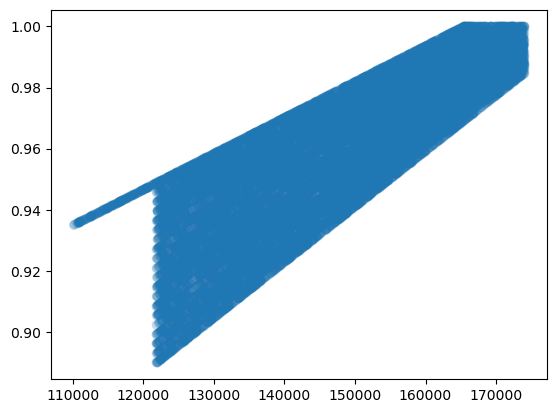

In [36]:
plt.scatter(weight_lst, throttle_lst, alpha=0.1)
plt.show()

In [43]:
Data_Weight = Data_Weight[Data_Weight["Total_Weight"]>123000]

In [44]:
n1 = 0.8
n2 = 0.9
Data_Weight.dropna(inplace=True)
train, val, test = np.split(Data_Weight.sample(frac=1, random_state=42), [int(n1*len(Data_Weight)), int(n2*len(Data_Weight))])

In [45]:
train

array([[np.float64(172.59819135321308), np.float64(172.19165105405062),
        np.float64(7.346264215503775), ...,
        'Data\\Departures\\2024-07-18---20-16-51.csv',
        172.02949658409236, 22488.031993943423],
       [np.float64(150.23499004854705), np.float64(168.04741789165297),
        np.float64(29.22954769591382), ...,
        'Data\\Departures\\2024-07-27---17-21-19.csv',
        168.53475086119255, 20689.67636625471],
       [np.float64(159.7420445336437), np.float64(159.92317581176758),
        np.float64(19.15289661923647), ...,
        'Data\\Departures\\2024-07-27---06-15-21.csv', 158.5139833104306,
        16885.8493341272],
       ...,
       [np.float64(142.8357494627144), np.float64(159.21503226987778),
        np.float64(27.578242498140877), ...,
        'Data\\Departures\\2024-07-16---13-43-14.csv', 158.1562600047604,
        19397.12329734232],
       [np.float64(161.07236729969785), np.float64(157.90763201032365),
        np.float64(4.388259214734077), ...,

In [52]:
train = pd.DataFrame(train, columns = Data_Weight.columns) 
val = pd.DataFrame(val, columns = Data_Weight.columns)
test = pd.DataFrame(test, columns = Data_Weight.columns)

In [55]:
test

,Vg_1,Vc_1,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,climb_angle_1,...,theta_3,sigma_3,delta_3,roll_3,climb_angle_3,acc_max,Total_Weight,ID,Climb_CAS,Thrust_Max
0,158.374865,169.616113,10.86344,0.99533,0.066321,0.936929,1.012192,0.981059,-5.235552,10.297634,...,0.881883,0.7693,0.701831,-0.00027,7.330027,5.182957,162202.757819,Data\Departures\2024-07-28---18-45-50.csv,169.95074,25327.02295
1,136.908853,153.830988,17.043633,0.982666,-0.130336,0.944154,1.01905,0.995319,12.033464,14.115241,...,0.887821,0.774996,0.711789,0.000005,9.171222,4.857361,126134.01337,Data\Departures\2024-07-26---08-27-12.csv,153.155438,20759.240684
2,163.91462,161.804324,12.644105,0.965307,-0.17274,0.946238,0.847583,0.829673,10.293367,7.165854,...,0.889398,0.64414,0.592655,-0.00027,5.383932,4.390213,139552.401932,Data\Departures\2024-07-13---06-12-00.csv,160.615154,17939.430497
3,158.31582,166.142201,15.947592,0.997431,0.055067,0.990089,0.915337,0.937539,-1.90197,9.26201,...,0.927498,0.70561,0.677026,-0.000004,6.795367,4.308073,158505.345482,Data\Departures\2024-07-18---23-35-34.csv,166.067309,22461.892685
4,137.63154,152.003075,26.689808,0.998272,0.042644,0.965505,0.864295,0.86325,-4.401431,9.441092,...,0.905679,0.659505,0.617902,-0.008226,6.762543,4.53237,126996.746737,Data\Departures\2024-07-28---07-21-59.csv,152.90057,17878.761939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,137.873257,160.219517,28.347199,0.999123,-0.028113,0.962168,0.939993,0.935616,2.667014,11.288081,...,0.902301,0.714621,0.667042,-0.000275,7.913601,4.635557,146123.068019,Data\Departures\2024-07-27---05-22-43.csv,161.615589,22037.43935
2504,166.948335,172.593192,12.325812,0.985236,0.170514,1.00656,0.936353,0.974989,-5.411981,9.635231,...,0.938023,0.711691,0.690609,-0.001023,6.229562,4.621695,168278.551332,Data\Departures\2024-07-13---16-20-19.csv,172.186931,23392.575365
2505,165.669084,162.150546,7.508218,0.997133,0.044645,0.956889,0.880348,0.871442,-4.984878,7.563932,...,0.897776,0.668299,0.620675,0.00049,5.555831,4.253767,142255.041687,Data\Departures\2024-07-11---11-44-01.csv,163.453953,18784.880729
2506,124.079934,151.167827,28.325548,0.997408,-0.047946,0.953442,0.998642,0.984975,6.335383,15.080409,...,0.895164,0.758784,0.702662,0.00031,9.976132,5.355523,128004.876037,Data\Departures\2024-07-23---11-44-03.csv,153.416497,22178.266346


In [56]:
pd.concat([train, val]).to_csv("Data/Data_Train_Weight_Dep.csv", index=False)
test.to_csv("Data/Data_Test_Weight_Dep.csv", index=False)

In [57]:
Data_Weight.shape

(25073, 34)

# Read Training Data

In [61]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")

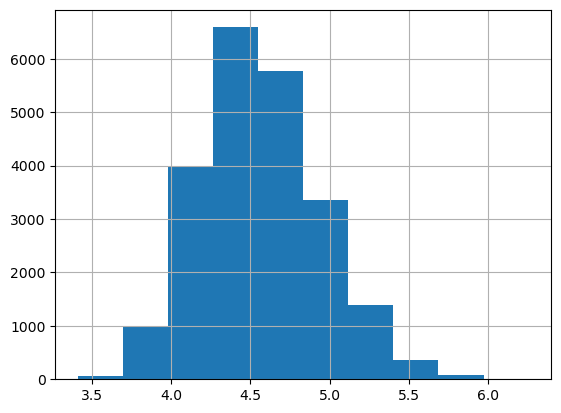

In [62]:
Data["acc_max"].hist()
plt.show()

In [63]:
Data[desired_columns].corr()["Total_Weight"].sort_values()

climb_angle_1    -0.433369
climb_angle_3    -0.327946
acc_max          -0.275748
acc              -0.275228
climb_angle_2    -0.139503
theta_3          -0.058584
theta_1          -0.056205
theta_2          -0.049610
wind_dir_sin_3   -0.012893
wind_dir_sin_2   -0.010193
wind_speed_2     -0.008704
wind_dir_cos_1   -0.007791
wind_speed_1     -0.006966
wind_speed_3     -0.006928
Vg_3             -0.005271
roll_1           -0.001415
roll_3            0.005069
wind_dir_sin_1    0.007847
wind_dir_cos_3    0.032680
wind_dir_cos_2    0.032877
roll_2            0.046955
delta_3           0.118981
delta_2           0.125501
delta_1           0.126547
sigma_3           0.136021
sigma_2           0.140358
sigma_1           0.141822
Vg_1              0.408637
Vc_3              0.929729
Vc_1              0.973567
Total_Weight      1.000000
Name: Total_Weight, dtype: float64

In [66]:
# all_names = desired_columns
all_names = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight"]
x_names = all_names[:-1]

In [67]:
# scaler = StandardScaler().fit(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values)
# Data_scaled = pd.DataFrame(scaler.transform(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data.index, columns=Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [68]:
n1 = 0.8
n2 = 0.9
# X_train, X_val, y_train, y_val = train_test_split(Data_scaled[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]], Data_scaled[['Total_Weight']], test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Total_Weight']], test_size=(n2-n1)/n2)

# Create the Weight Model

In [69]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [70]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Weight Model

## 1st LR

In [71]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [72]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1891 - val_loss: 0.1690
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - loss: 0.1722 - val_loss: 0.1735
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step - loss: 0.1692 - val_loss: 0.1706
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step - loss: 0.1670 - val_loss: 0.1580
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - loss: 0.1677 - val_loss: 0.1633
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - loss: 0.1668 - val_loss: 0.1737
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - loss: 0.1666 - val_loss: 0.1685


In [73]:
losses = pd.DataFrame(model.history.history)

## 2nd LR

In [74]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [75]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [76]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - loss: 0.1535 - val_loss: 0.1540
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - loss: 0.1522 - val_loss: 0.1542
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - loss: 0.1521 - val_loss: 0.1532
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - loss: 0.1518 - val_loss: 0.1535
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - loss: 0.1521 - val_loss: 0.1528


In [77]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [78]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=1)

In [79]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [80]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - loss: 0.1506 - val_loss: 0.1517
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - loss: 0.1501 - val_loss: 0.1517


In [81]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step
mae =  1.6062115220462574


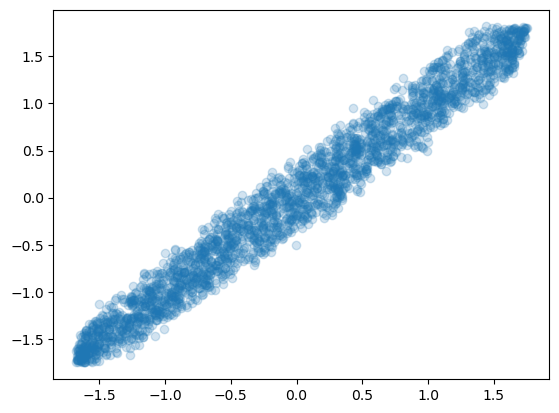

In [82]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)
plt.show()

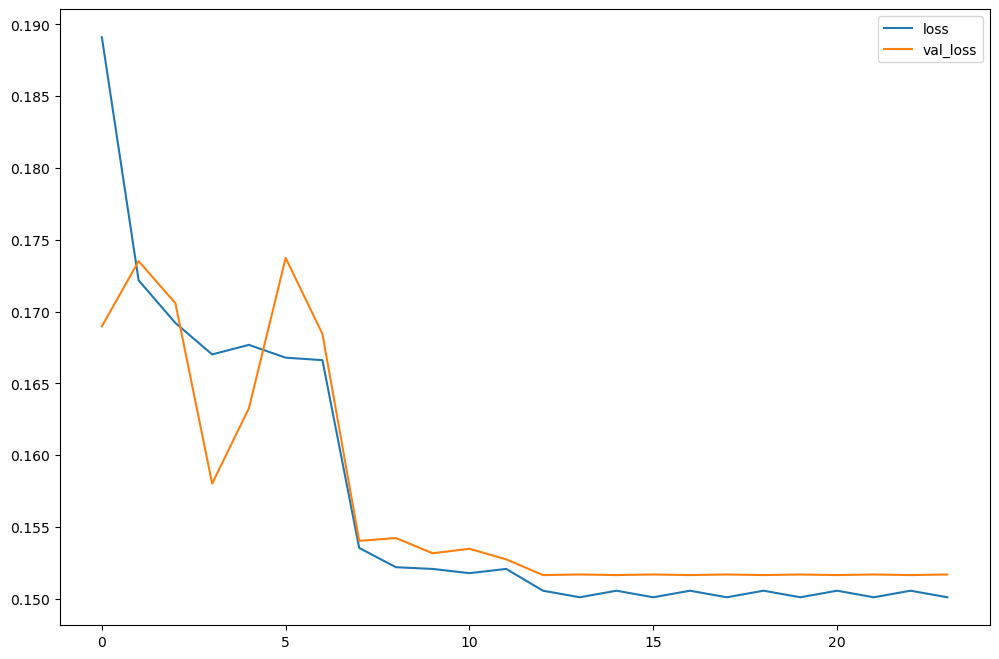

In [89]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))
plt.show()

# Test Score

In [90]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [91]:
# Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data_test.index, columns=Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [92]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Total_Weight"]]

In [93]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step


In [94]:
mae_current = mean_absolute_error(y_test_scaled, y_pred_scaled)
print("mae = ", mae_current*18000/170000*100)

mae =  1.595019768266117


In [95]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [96]:
print("r2 score for weight predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for weight predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Total_Weight"], output[:,-1])))
print("MAE score for weight predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Total_Weight"]-output[:,-1])*Data_test["Total_Weight"]**-1))
print("Maximum error for weight predictions: %.5f" % np.max(np.abs(Data_test["Total_Weight"]-output[:,-1])))

r2 score for weight predictions: 0.96742
MAE score for weight predictions: 2120.05034
MAE score for weight predictions as percentage: 1.43446 %
Maximum error for weight predictions: 8826.67750


In [97]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

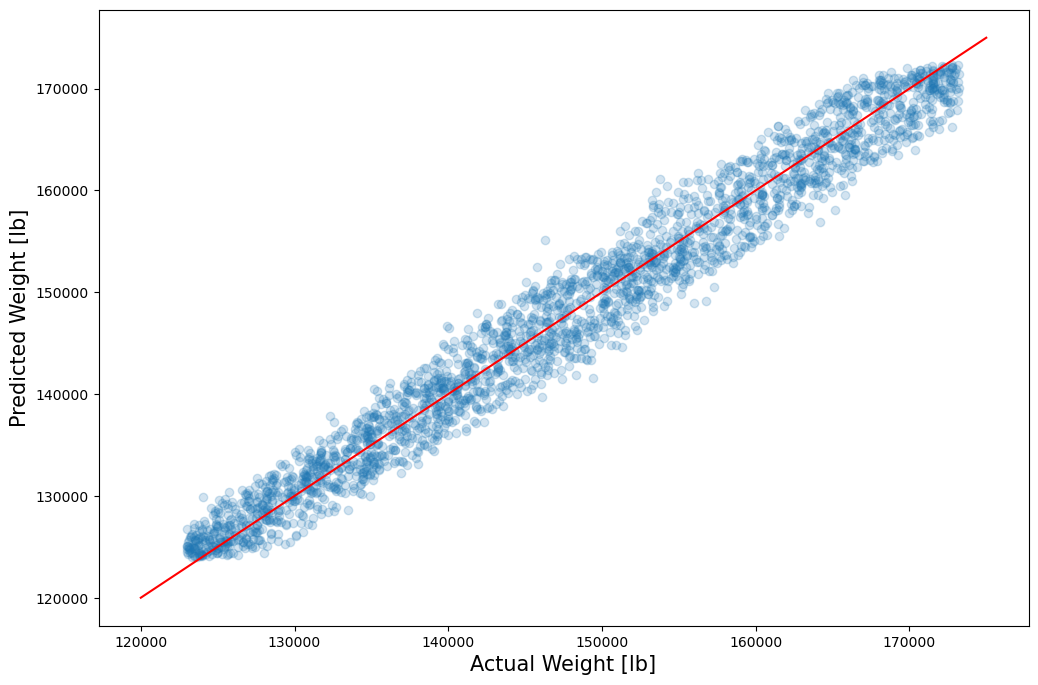

In [98]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Total_Weight"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [lb]", fontsize=15)
plt.xlabel("Actual Weight [lb]", fontsize=15)
plt.plot([120000, 175000], [120000, 175000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_scatter.png", dpi=300)
plt.show()

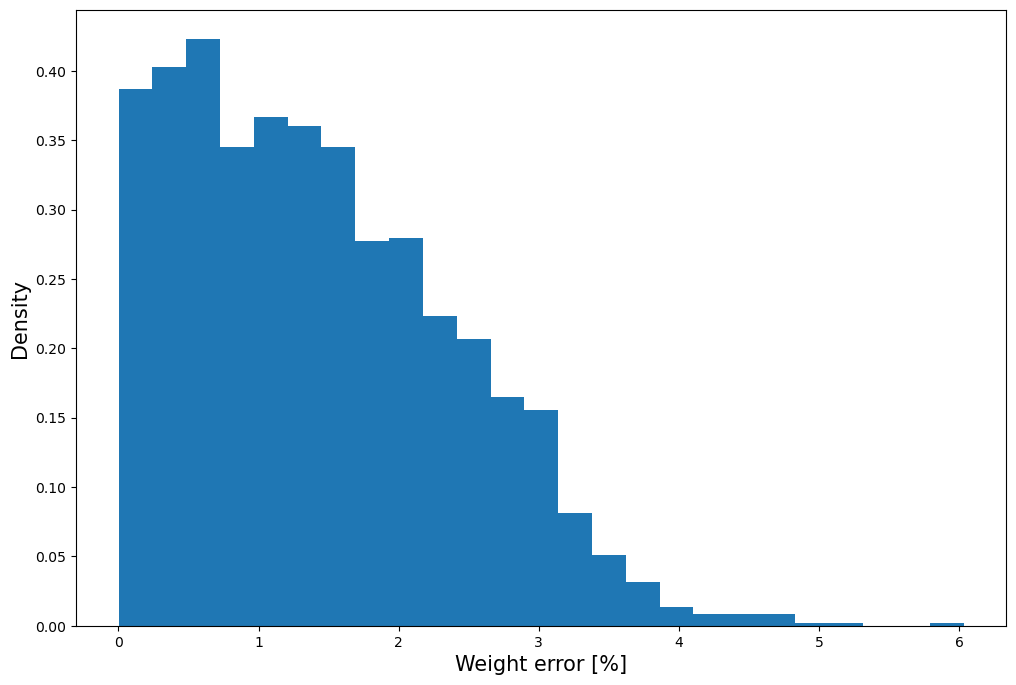

In [99]:
errors_lst = np.abs(100*(output[:,-1] - Data_test["Total_Weight"].values)/Data_test["Total_Weight"])
plt.figure(figsize=(12,8))
plt.hist(errors_lst, bins=25, ec="k", density=True)
plt.xlabel("Weight error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
# plt.xlim([-5,5])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_1.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_error_distribution.png", dpi=300)
plt.show()

# Save Model

In [101]:
model.save("Models\model_weight\model_weight.keras")
dump(scaler, "Models\model_weight\scaler_weight.bin", compress=True)

['Models\\model_weight\\scaler_weight.bin']

# Thrust Model Data Gathering

In [102]:
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]

In [103]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])

In [104]:
len(f_lst_test)

2508

In [105]:
n = 0.9
f_lst_train = [f for f in f_lst if f not in f_lst_test]
random.shuffle(f_lst_train)  # shuffle in-place
train_end = int(n * len(f_lst_train))
train = f_lst_train[:train_end]
val = f_lst_train[train_end:]
test = f_lst_test

In [106]:
Data_Train_thrust = pd.DataFrame(columns=thrust_columns)
Data_Val_thrust = pd.DataFrame(columns=thrust_columns)
Data_Test_Thrust = pd.DataFrame(columns=thrust_columns)

In [107]:
dfs = []
for f in train[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Train_Thrust = pd.concat(dfs, ignore_index=True)
Data_Train_Thrust.to_csv("Data/Data_Train_Thrust_Dep.csv", index=False)

dfs = []
for f in val[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Val_Thrust = pd.concat(dfs, ignore_index=True)
Data_Val_Thrust.to_csv("Data/Data_Val_Thrust_Dep.csv", index=False)

dfs = []
for f in test[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Test_Thrust = pd.concat(dfs, ignore_index=True)
Data_Test_Thrust.to_csv("Data/Data_Test_Thrust_Dep.csv", index=False)


# Read the Data for Thrust Model

In [108]:
Data_train = pd.read_csv("Data\Data_Train_Thrust_Dep.csv")
Data_val = pd.read_csv("Data\Data_Val_Thrust_Dep.csv")
Data_test = pd.read_csv("Data\Data_Test_Thrust_Dep.csv")

In [109]:
scaler = StandardScaler().fit(Data_train.values)

In [110]:
Data_train_scaled = pd.DataFrame(scaler.transform(Data_train.values), index=Data_train.index, columns=Data_train.columns)
Data_train_scaled.dropna(inplace=True)

In [111]:
Data_val_scaled = pd.DataFrame(scaler.transform(Data_val.values), index=Data_val.index, columns=Data_val.columns)
Data_val_scaled.dropna(inplace=True)

In [112]:
X_train = Data_train_scaled[thrust_columns[:-1]]
y_train = Data_train_scaled[['Thrust']]
X_val = Data_val_scaled[thrust_columns[:-1]]
y_val = Data_val_scaled[['Thrust']]

In [113]:
X_train.shape

(6349085, 12)

# Create the Thrust Model

In [114]:
model = Sequential()
model_dropout = 0.02
model_activation = 'sigmoid'
batch_size = 256

model.add(Dense(64, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(64, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(32, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [115]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,617 (29.75 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Thrust Model

## 1st LR

In [116]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [117]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.1297 - val_loss: 0.1029
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 0.1115 - val_loss: 0.1107
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.1068 - val_loss: 0.0977
Epoch 4/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 0.1044 - val_loss: 0.0892
Epoch 5/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.1029 - val_loss: 0.0908
Epoch 6/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.1018 - val_loss: 0.0920
Epoch 7/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.1007 - val_loss: 0.0937


In [122]:
losses = pd.DataFrame(model.history.history)


## 2nd LR

In [123]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [124]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [125]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0946 - val_loss: 0.0848
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0942 - val_loss: 0.0838
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0940 - val_loss: 0.0849
Epoch 4/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0939 - val_loss: 0.0831
Epoch 5/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0937 - val_loss: 0.0833
Epoch 6/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0936 - val_loss: 0.0825
Epoch 7/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0934 - val_loss: 0.0837
Epoch 8/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0934 - val_loss: 0.0841


In [126]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [127]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [128]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [129]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0927 - val_loss: 0.0831
Epoch 2/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.0926 - val_loss: 0.0828
Epoch 3/50
24802/24802 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.0927 - val_loss: 0.0831


In [132]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))


<Axes: >

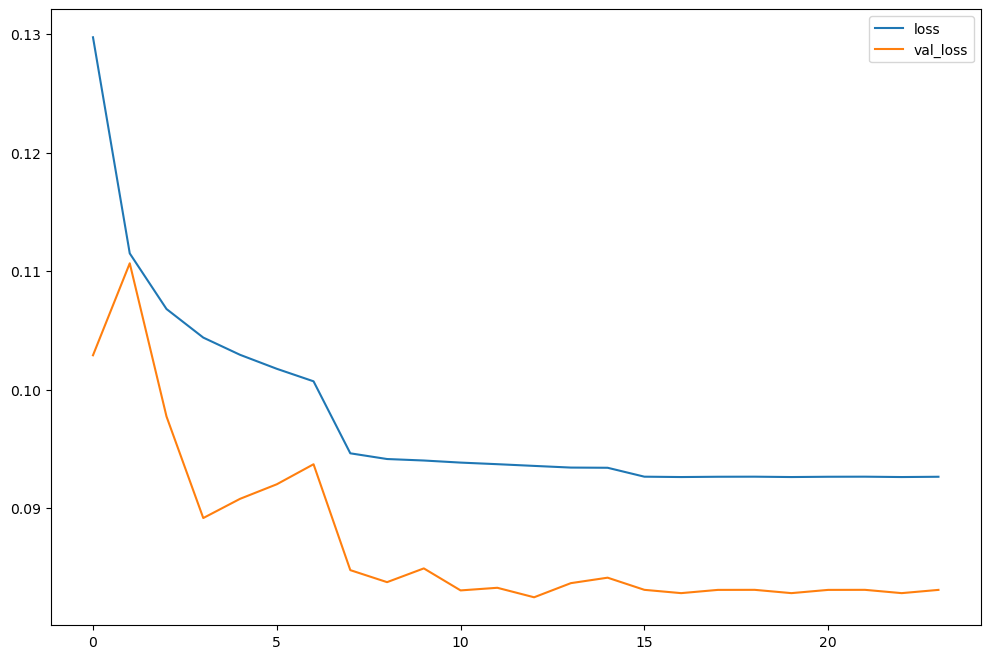

In [133]:
plt.show()

# Test Score

In [134]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test.values), index=Data_test.index, columns=Data_test.columns)
Data_test_scaled.dropna(inplace=True)

In [135]:
X_test_scaled = Data_test_scaled[thrust_columns[:-1]]
y_test_scaled = Data_test_scaled[['Thrust']]

In [136]:
y_pred_scaled = model.predict(X_test_scaled)

19152/19152 ━━━━━━━━━━━━━━━━━━━━ 9s 468us/step


In [137]:
print("r2 score for thrust predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust predictions: %.5f" % (metrics.mean_absolute_error(y_test_scaled, y_pred_scaled)))
print("Maximum error for thrust predictions: %.5f" % np.max(y_pred_scaled-y_test_scaled))

r2 score for thrust predictions: 0.98366
MAE score for thrust predictions: 0.07647
Maximum error for thrust predictions: 4.50957


# Save Model

In [138]:
model.save("Models\model_thrust\model_thrust.keras")
dump(scaler, "Models\model_thrust\scaler_thrust.bin", compress=True)

['Models\\model_thrust\\scaler_thrust.bin']

# Predict Outputs for a Single Flight

In [139]:
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")

In [140]:
test_flight = pd.read_csv(test[200])

In [141]:
flight_data = test_flight[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

start_time = time.time()
y_pred_scaled = model_thrust.predict(X_flight)
# y_pred_scaled = model_thrust(X_flight)
# y_pred_tensor = y_pred_scaled['dense_9']
# y_pred_np = y_pred_tensor.numpy().reshape(-1, 1)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
# output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_np), axis=1))
#output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]
end_time = time.time()
print(end_time - start_time)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
0.13520073890686035


In [142]:
print("r2 score for thrust predictions with exact weight: %.5f" % (metrics.r2_score(flight_data["Thrust"], y_pred)))
print("MAE score for thrust predictions with exact weight: %.5f" % (metrics.mean_absolute_error(flight_data["Thrust"], y_pred)))
print("Maximum error for thrust predictions with exact weight: %.5f" % np.max(y_pred-flight_data["Thrust"]))

r2 score for thrust predictions with exact weight: 0.96281
MAE score for thrust predictions with exact weight: 316.88785
Maximum error for thrust predictions with exact weight: 1237.29997


In [210]:
y_pred

array([ 4962.02825027, 14335.41739121, 22237.6559622 , 24343.70888566,
       24483.72959296, 24360.26291116, 24179.75216771, 24062.6099317 ,
       23937.09816558, 23783.91088524, 23541.5285446 , 23432.44744747,
       23243.54291842, 23015.14698639, 22880.38001825, 22746.49179187,
       22588.65646661, 22401.89127178, 22263.77496697, 22146.80529145,
       22046.52893723, 21917.39270787, 21821.55649438, 21706.32281894,
       21580.21367474, 21469.89346859, 21210.8406761 , 21180.06738928,
       21290.72925135, 21270.68590034, 20665.75120487, 21223.80419604,
       21353.81293003, 21139.8878234 , 21313.05816253, 20759.67677876,
       21095.27851202, 21057.87585325, 20921.46921398, 20821.20672005,
       20762.33933856, 20727.39757252, 20664.28340121, 20663.64790737,
       20730.06082533, 20783.32103052, 20779.42351977, 19636.73421328,
       19383.49615479, 19338.38406174, 19300.40966642, 19181.8911046 ,
       19096.11502889, 18990.6185467 , 18913.87972009, 18871.72298526,
      

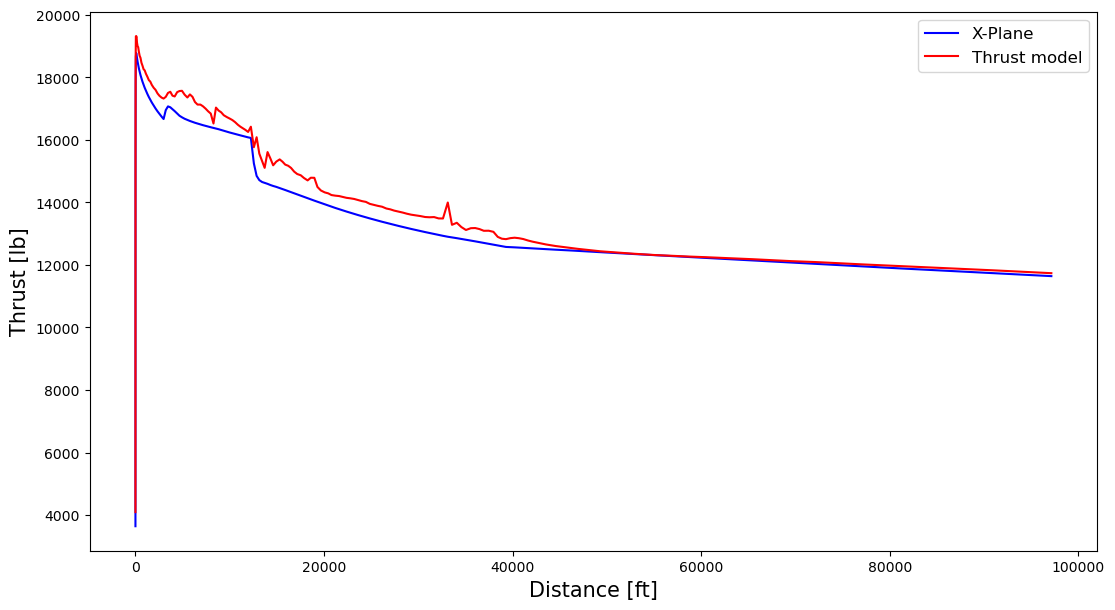

In [143]:
plt.figure(figsize=(13,7))
plt.plot(test_flight["Distance"], test_flight["Thrust"], "b")
plt.plot(test_flight["Distance"], y_pred, "r")
plt.xlabel("Distance [ft]", fontsize=15)
plt.ylabel("Thrust [lb]", fontsize=15)
plt.legend(["X-Plane", "Thrust model"], fontsize=12)
# plt.xticks(ticks=[0,20000,40000,60000,80000,100000,120000,140000], labels=["0","20,000","40,000",""])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Thrust_0.png", bbox_inches="tight", facecolor='white', transparent=False)

plt.savefig("thrust_predictions_single_flight.png", dpi=300)
plt.show()

## Normal Thrust Model Error on Max Thrust Values

In [144]:
df_results = pd.DataFrame(columns = ["R2", "MAE", "Thrust_Max_Pred", "Thrust_Max_Actual", "Thrust_Maxx_Error_Perc"])
i = 0
for f in test:
    test_flight = pd.read_csv(f)
    flight_data = test_flight[thrust_columns]
    flight_data.dropna(inplace=True)
    flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[thrust_columns[:-1]]
    
    y_pred_scaled = model_thrust.predict(X_flight)
    output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]

    df_results.loc[i, "R2"] = metrics.r2_score(flight_data["Thrust"], y_pred)
    df_results.loc[i, "MAE"] = metrics.mean_absolute_error(flight_data["Thrust"], y_pred)
    df_results.loc[i, "Thrust_Max_Pred"] = np.max(y_pred)
    df_results.loc[i, "Thrust_Max_Actual"] = np.max(flight_data["Thrust"])
    df_results.loc[i, "Thrust_Max_Error_Perc"] = 100*np.abs(df_results.loc[i, "Thrust_Max_Pred"]-df_results.loc[i, "Thrust_Max_Actual"])/df_results.loc[i, "Thrust_Max_Actual"]
    i += 1

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━

In [145]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(df_results["Thrust_Max_Error_Perc"]))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(df_results["Thrust_Max_Actual"]-df_results["Thrust_Max_Pred"])))

r2 score for thrust max predictions: 0.94084
MAE score for thrust max predictions: 378.18173
MAE score for thrust max predictions as percentage: 1.84462 %
Maximum error for thrust max predictions: 2664.69855


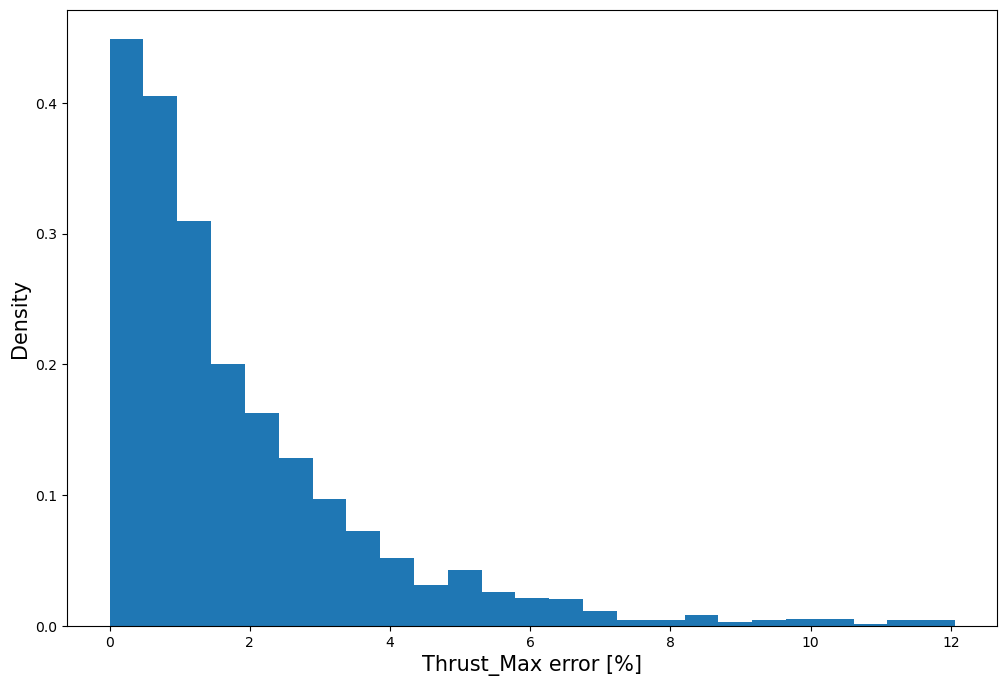

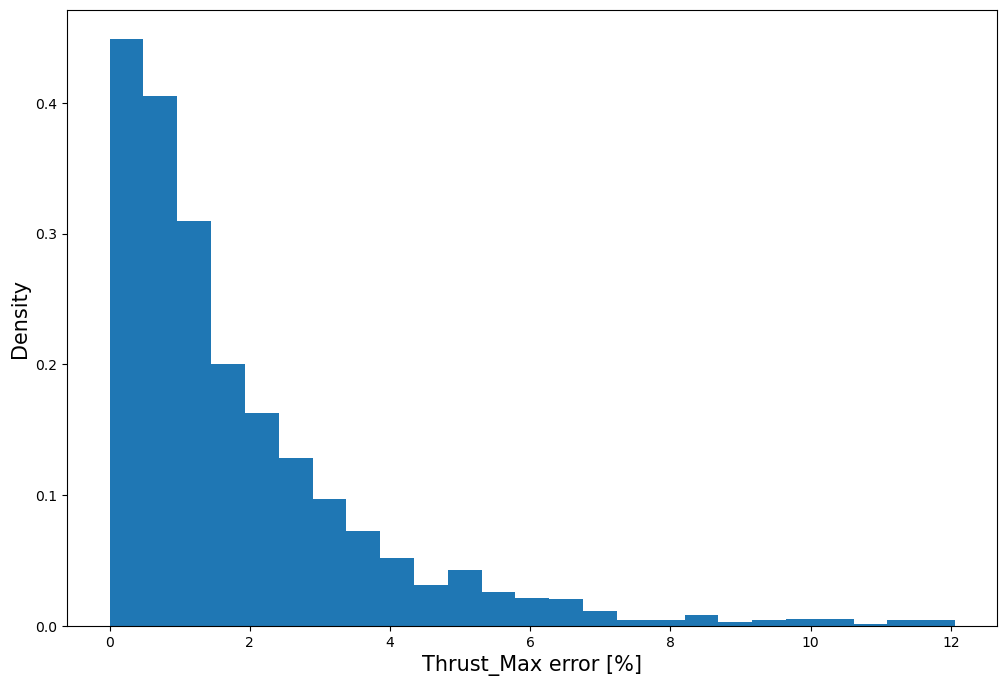

In [147]:
plt.figure(figsize=(12,8))
plt.hist(df_results["Thrust_Max_Error_Perc"], bins=25, ec="k", density=True)
plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.show()

# Thrust Max Model

In [148]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")
n1 = 0.8
n2 = 0.9

In [149]:
# all_names = desired_columns
all_names = ["acc_max", "Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight", "Thrust_Max"]
x_names = all_names[:-1]

In [150]:
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [151]:
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Thrust_Max']], test_size=(n2-n1)/n2)

## Create the Model

In [152]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [153]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

## Train the thrust max Model

### 1st LR

In [154]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [155]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 854us/step - loss: 0.2276 - val_loss: 0.2396
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - loss: 0.2054 - val_loss: 0.1987
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - loss: 0.2015 - val_loss: 0.2052
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - loss: 0.1973 - val_loss: 0.2049
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - loss: 0.1995 - val_loss: 0.2029


In [156]:
losses = pd.DataFrame(model.history.history)

### 2nd LR

In [157]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [158]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [159]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - loss: 0.1789 - val_loss: 0.1810
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - loss: 0.1769 - val_loss: 0.1795
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.1761 - val_loss: 0.1798
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - loss: 0.1753 - val_loss: 0.1774
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - loss: 0.1747 - val_loss: 0.1765
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - loss: 0.1745 - val_loss: 0.1767
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.1740 - val_loss: 0.1769


In [160]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

### 3rd LR

In [161]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [162]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [163]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - loss: 0.1714 - val_loss: 0.1742
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.1712 - val_loss: 0.1743
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.1710 - val_loss: 0.1744


In [164]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
mae =  1.8468189239501953


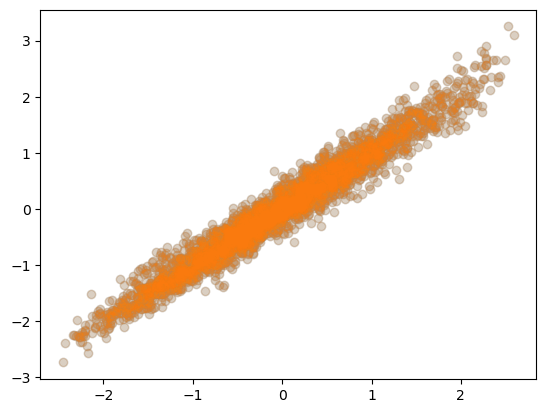

In [166]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)
plt.show()

In [170]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))


<Axes: >

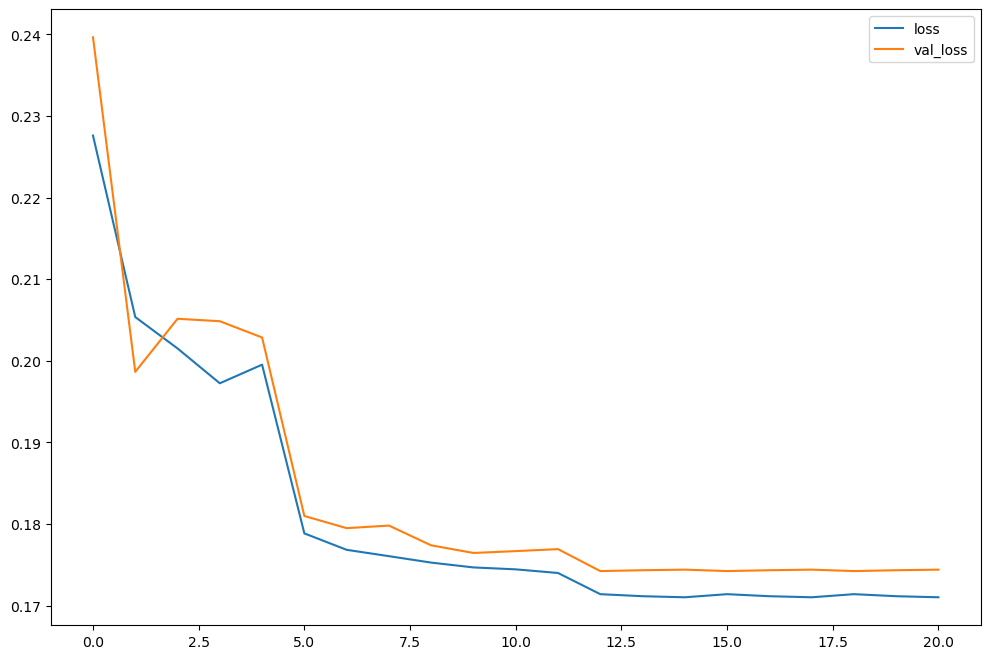

In [171]:
plt.show()

## Test Score

In [172]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [173]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [174]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Thrust_Max"]]

In [175]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step


In [176]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [177]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Thrust_Max"], output[:,-1])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Thrust_Max"]-output[:,-1])*Data_test["Thrust_Max"]**-1))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(Data_test["Thrust_Max"]-output[:,-1])))

r2 score for thrust max predictions: 0.94981
MAE score for thrust max predictions: 382.26181
MAE score for thrust max predictions as percentage: 1.82117 %
Maximum error for thrust max predictions: 1835.02743


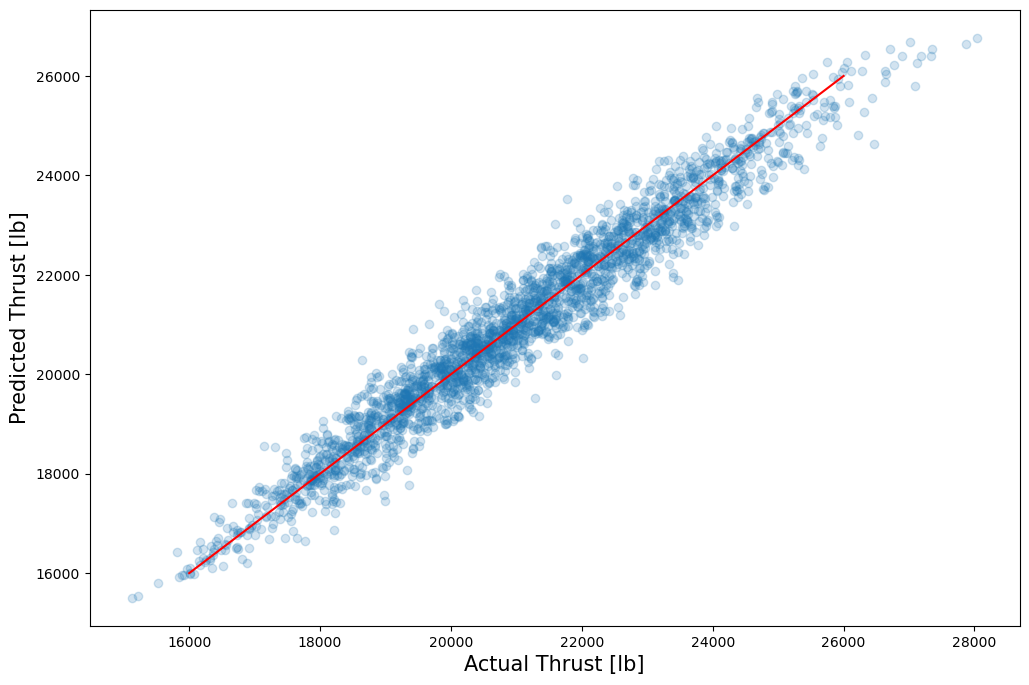

In [178]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Thrust_Max"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Thrust [lb]", fontsize=15)
plt.xlabel("Actual Thrust [lb]", fontsize=15)
plt.plot([16000, 26000], [16000, 26000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("thrust_max_predictions_scatter.png", dpi=300)
plt.show()

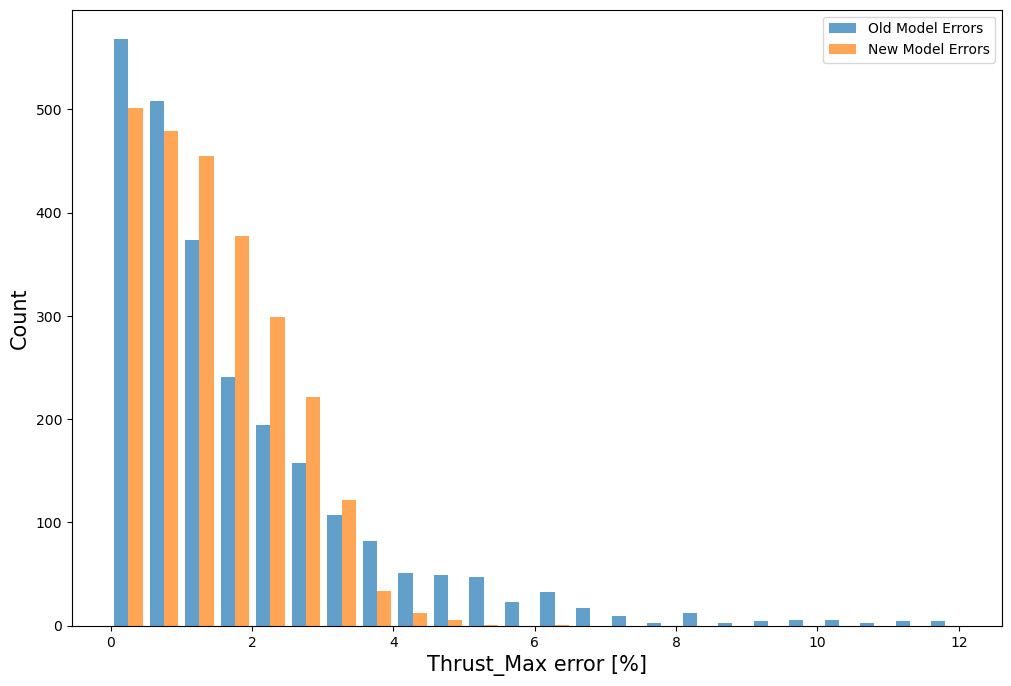

In [179]:
data1 = df_results["Thrust_Max_Error_Perc"]
data2 = errors_lst

# Compute bins
bins = np.linspace(min(data1.min(), data2.min()),
                   max(data1.max(), data2.max()), 25)

# Histogram counts
hist1, _ = np.histogram(data1, bins=bins)
hist2, _ = np.histogram(data2, bins=bins)

# Compute bin centers
bin_centers = 0.5 * (bins[1:] + bins[:-1])

width = (bins[1] - bins[0]) * 0.4

plt.figure(figsize=(12,8))
plt.bar(bin_centers - width/2, hist1, width=width, alpha=0.7, label="Old Model Errors")
plt.bar(bin_centers + width/2, hist2, width=width, alpha=0.7, label="New Model Errors")

plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.legend()
plt.savefig("thrust_max_predictions_comparison.png", dpi=300)
plt.show()

### Save the Model

In [180]:
model.save("Models\model_thrust\model_thrust_max.keras")
dump(scaler, "Models\model_thrust\scaler_thrust_max.bin", compress=True)

['Models\\model_thrust\\scaler_thrust_max.bin']

# RNN Thrust Model

In [181]:
Data_dir = "Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])
f_lst_train = [f for f in f_lst if f not in f_lst_test]

In [185]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---- ----------------------------------- 13.1/123.0 MB 68.3 MB/s eta 0:00:02
   ----- ---------------------------------- 18.1/123.0 MB 44.4 MB/s eta 0:00:03
   ------ --------------------------------- 20.7/123.0 MB 33.2 MB/s eta 0:00:04
   ------- -------------------------------- 23.9/123.0 MB 28.6 MB/s eta 0:00:04
   --------- ------------------------------ 29.1/123.0 MB 27.5 MB/s eta 0:00:04
   ----------- ---------------------------- 35.7/123.0 MB 28.2 MB/s eta 0:00:04
   -------------- ------------------------- 43.8/123.0 MB 29.6 MB/s eta 0:00:03
   ----------------- ---------------------- 53.2/123.0 MB 31.4 MB/s eta 0:00:03
   ------------------- -------------------- 61.3/123.0 MB 32.3 MB/s eta 0:00:02
   --------------------- ------------------ 66.8/123.0 MB 31.8 MB/s eta 0:00:02
   ------------------------ --------------- 73.9/12

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [186]:
# train_thrust_rnn.py
import os
import glob
import random
from typing import List, Tuple

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

# ------------------------
# Configuration / Hyperparams
# ------------------------
DATA_DIR = "Data/Departures"  # directory with flight CSVs
BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 1e-3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
TEACHER_FORCING_PROB = 1  # during training, probability to feed true previous thrust instead of model's
MIN_JUMP = 0  # seconds
MAX_JUMP = 8  # seconds
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------
# Feature list (as described by user)
# ------------------------
POINT_FEATURES = [
    "Altitude_Above_Ground",
    "Ground_Speed",
    "Acceleration",
    "theta",
    "delta",
    "sigma",
    "vpath",
    "Roll",
    "Wind_Speed",
    "Wind_dir_cos",
    "Wind_dir_sin",
    "Total_Weight",
]
# We'll add dt and prev_thrust at runtime -> input_dim = len(POINT_FEATURES) + 2

# ------------------------
# Preprocessing per-file (Time already in seconds)
# ------------------------
def sample_sequence_from_df(df: pd.DataFrame, rng=np.random) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For a single flight df:
    - find t0 = last time where Altitude_Above_Ground == 0
    - keep rows where Altitude_Above_Ground > 0
    - starting from t0, sample times by random jumps between MIN_JUMP and MAX_JUMP seconds
    - for each sampled time, choose the first row with Time >= sample_time
    - build input vectors: POINT_FEATURES + dt + prev_thrust
      - dt for first sample = time - t0
      - prev_thrust for first sample = max thrust on ground
      - for subsequent samples prev_thrust = true Thrust of previous sampled point
    - returns: inputs (T, feat_dim), targets (T,) = true Thrust at sampled points, times array (T,)
    """
    if "Time" not in df.columns:
        raise ValueError("DataFrame must contain 'Time' column")
    if "Thrust" not in df.columns:
        raise ValueError("DataFrame must contain 'Thrust' column")

    df = df.copy()

    # find last ground time t0
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if ground_rows.shape[0] == 0:
        return None
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # keep only airborne rows (Altitude_Above_Ground > 0) and times > t0
    air_df = df[df["Altitude_Above_Ground"] > 0].copy()
    air_df = air_df[air_df["Time"] > t0]
    if air_df.empty:
        return None

    # ensure sorted
    air_df = air_df.sort_values("Time").reset_index(drop=True)

    # sampling loop
    sampled_indices = []
    current_time = t0 + rng.randint(MIN_JUMP, MAX_JUMP)
    while True:
        # find first index in air_df with time >= current_time
        candidates = air_df[air_df["Time"] >= current_time]
        if candidates.empty:
            break
        idx = int(candidates.index[0])
        if sampled_indices and idx == sampled_indices[-1]:
            current_time += 1.0
            continue
        sampled_indices.append(idx)
        current_time += rng.randint(MIN_JUMP, MAX_JUMP)

    if len(sampled_indices) == 0:
        return None

    sampled = air_df.loc[sampled_indices].reset_index(drop=True)
    times = sampled["Time"].values.astype(float)
    targets = sampled["Thrust"].values.astype(float)

    # build inputs
    dt = np.empty(len(times), dtype=float)
    prev_thrust = np.empty(len(times), dtype=float)
    inputs = []
    for i in range(len(times)):
        if i == 0:
            dt[i] = times[0] - t0
            prev_thrust[i] = max_ground_thrust
        else:
            dt[i] = times[i] - times[i - 1]
            prev_thrust[i] = targets[i - 1]
        row_feats = sampled.loc[i, POINT_FEATURES].values.astype(float)
        inp = np.concatenate([row_feats, [dt[i], prev_thrust[i]]])
        inputs.append(inp)

    inputs = np.vstack(inputs)
    return inputs, targets.astype(float), times.astype(float)


# ------------------------
# Dataset and Collate
# ------------------------
class FlightSequenceDataset(Dataset):
    def __init__(self, file_list: List[str], rng_seed=SEED):
        self.files = file_list
        self.rng = np.random.RandomState(rng_seed)
        # We'll store processed sequences in memory to keep DataLoader simple
        self.sequences = []  # list of tuples (inputs ndarray (T, D), targets ndarray (T,), times ndarray (T,))
        for f in tqdm(self.files, desc="Preparing sequences"):
            try:
                df = pd.read_csv(f)
                df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
            except Exception as e:
                print(f"Skipping {f}: cannot read ({e})")
                continue
            result = sample_sequence_from_df(df, rng=self.rng)
            if result is None:
                continue
            inputs, targets, times = result
            # skip tiny sequences
            if inputs.shape[0] < 3:
                continue
            self.sequences.append((inputs, targets, times))

        if len(self.sequences) == 0:
            raise RuntimeError("No sequences extracted. Check your data files and preprocessing assumptions.")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        inputs, targets, times = self.sequences[idx]
        return {
            "inputs": torch.tensor(inputs, dtype=torch.float32),
            "targets": torch.tensor(targets, dtype=torch.float32),
            "length": inputs.shape[0],
            "times": torch.tensor(times, dtype=torch.float32),
        }

def collate_fn(batch):
    """
    Pads inputs and targets to the max sequence length in the batch.
    Returns:
      inputs_padded: (batch, maxT, D)
      targets_padded: (batch, maxT)
      lengths: list of lengths
      mask: (batch, maxT) 1 where valid
    """
    inputs = [item["inputs"] for item in batch]
    targets = [item["targets"] for item in batch]
    lengths = [int(item["length"]) for item in batch]

    # pad inputs (pad_sequence pads along dim=0 to max length)
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0.0)  # (B, maxT, D)
    targets_padded = pad_sequence([t.unsqueeze(1) for t in targets], batch_first=True, padding_value=0.0).squeeze(-1)
    # mask
    maxT = inputs_padded.size(1)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    for i, L in enumerate(lengths):
        mask[i, :L] = True

    return {
        "inputs": inputs_padded,
        "targets": targets_padded,
        "lengths": torch.tensor(lengths, dtype=torch.long),
        "mask": mask,
    }

# ------------------------
# Scaler utilities (fit on training sequences)
# ------------------------
def fit_scalers(dataset: FlightSequenceDataset):
    # concat all inputs to fit a StandardScaler for features except prev_thrust maybe should be scaled too
    all_inputs = np.vstack([seq[0] for seq in dataset.sequences])  # (N_total, D)
    scaler = StandardScaler()
    scaler.fit(all_inputs)  # scale everything including prev_thrust and dt
    return scaler

def apply_scaler_to_sequence_array(inputs: np.ndarray, scaler: StandardScaler):
    """
    inputs shape (T, D)
    returns scaled inputs of same shape
    """
    return scaler.transform(inputs)

# ------------------------
# Model
# ------------------------
class ThrustRNN(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int = 128, n_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_size,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x_packed):
        # x_packed: PackedSequence (from pack_padded_sequence)
        packed_out, _ = self.lstm(x_packed)
        out, lengths = pad_packed_sequence(packed_out, batch_first=True)  # (B, maxT, hidden)
        # apply head time-distributed
        B, T, H = out.shape
        out_flat = out.contiguous().view(B * T, H)
        preds_flat = self.head(out_flat).view(B, T)
        return preds_flat  # (B, T)

# ------------------------
# Training loop helpers
# ------------------------
def masked_mse(preds, targets, mask):
    # preds, targets: (B, T), mask: bool (B, T)
    diff = (preds - targets) * mask.to(preds.dtype)
    mse = (diff ** 2).sum() / (mask.sum().to(preds.dtype) + 1e-8)
    return mse

def train_epoch(model, dataloader, optimizer, scaler, teacher_prob=0.9):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="training batch progress"):
        inputs = batch["inputs"].to(DEVICE)  # (B, T, D)
        targets = batch["targets"].to(DEVICE)  # (B, T)
        lengths = batch["lengths"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)

        B, T, D = inputs.shape

        # scale inputs per-feature using scaler
        # scaler expects numpy, so we transform batchwise
        # convert to numpy -> apply scaler -> back to torch
        inp_np = inputs.cpu().numpy().reshape(-1, D)
        inp_np_scaled = scaler.transform(inp_np)
        inputs_scaled = torch.tensor(inp_np_scaled.reshape(B, T, D), dtype=torch.float32, device=DEVICE)

        # Pack sequence
        packed = pack_padded_sequence(inputs_scaled, lengths.cpu(), batch_first=True, enforce_sorted=False)

        optimizer.zero_grad()

        # Forward through LSTM head to get model predictions
        preds = model(packed)  # (B, T)

        # Training uses teacher forcing in inputs (prev_thrust inside inputs were prepared using true previous thrust)
        # But if you want to sometimes use model predictions as prev_thrust, you would need to implement a step-wise loop
        # and re-feed predicted prev_thrust into the inputs. For simplicity and stability we use teacher forcing here,
        # controlled at dataset build time via the prev_thrust values. However we'll implement a small scheduled sampling:
        # if teacher_prob < 1, perform a roll-forward correction: replace inputs' prev_thrust with model preds
        if teacher_prob < 1.0:
            # Reconstruct prev_thrust channel index (it's last channel)
            prev_idx = D - 1
            inputs_tf = inputs_scaled.clone()
            for b in range(B):
                L = lengths[b].item()
                for t in range(1, L):
                    if random.random() > teacher_prob:
                        # replace inputs_tf[b, t, prev_idx] with preds[b, t-1]
                        inputs_tf[b, t, prev_idx] = preds[b, t - 1].detach()
            # re-pack and reforward
            packed2 = pack_padded_sequence(inputs_tf, lengths.cpu(), batch_first=True, enforce_sorted=False)
            preds = model(packed2)

        loss = masked_mse(preds, targets, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * B

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

def save_datasets(train_ds, val_ds, path="Data/thrust_rnn_datasets.pt"):
    torch.save({
        "train_sequences": train_ds.sequences,
        "val_sequences": val_ds.sequences,
    }, path)
    print(f"Saved datasets to {path}")

def load_datasets(path="Data/thrust_rnn_datasets.pt"):
    data = torch.load(path, map_location="cpu", weights_only=False)

    # Rebuild datasets without re-processing files
    train_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    train_ds.files = []
    train_ds.rng = np.random.RandomState(42)
    train_ds.sequences = data["train_sequences"]

    val_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    val_ds.files = []
    val_ds.rng = np.random.RandomState(43)
    val_ds.sequences = data["val_sequences"]

    return train_ds, val_ds

def eval_epoch(model, dataloader, scaler):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="eval batch progress"):
            inputs = batch["inputs"].to(DEVICE)
            targets = batch["targets"].to(DEVICE)
            lengths = batch["lengths"].to(DEVICE)
            mask = batch["mask"].to(DEVICE)

            B, T, D = inputs.shape
            inp_np = inputs.cpu().numpy().reshape(-1, D)
            inp_np_scaled = scaler.transform(inp_np)
            inputs_scaled = torch.tensor(inp_np_scaled.reshape(B, T, D), dtype=torch.float32, device=DEVICE)

            packed = pack_padded_sequence(inputs_scaled, lengths.cpu(), batch_first=True, enforce_sorted=False)
            preds = model(packed)
            loss = masked_mse(preds, targets, mask)
            total_loss += loss.item() * B
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

# Create Dataset

In [187]:
# ------------------------
# Putting it together: main()
# ------------------------
# 1) collect files
# file_list = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
file_list = copy.copy(f_lst_train)
if len(file_list) == 0:
    raise RuntimeError(f"No CSV files in {DATA_DIR}")

# split train/val
random.shuffle(file_list)
n_train = int(0.8 * len(file_list))
train_files = file_list[:n_train]
val_files = file_list[n_train:]

# 2) build datasets
train_ds = FlightSequenceDataset(train_files, rng_seed=SEED)
val_ds = FlightSequenceDataset(val_files, rng_seed=SEED + 1)
save_datasets(train_ds, val_ds)

# 3) fit scaler on train set
scaler = fit_scalers(train_ds)
dump(scaler, "Models/model_thrust/scaler_thrust_rnn.bin", compress=True)

Preparing sequences: 100%|██████████| 6160/6160 [06:52<00:00, 14.92it/s]


Saved datasets to Data/thrust_rnn_datasets.pt


['Models/model_thrust/scaler_thrust_rnn.bin']

# Train the Model

In [188]:
train_ds, val_ds = load_datasets()

# store input dim
sample_item = train_ds[0]["inputs"]
input_dim = sample_item.shape[1]

# 4) dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 5) model
model = ThrustRNN(input_dim=input_dim, hidden_size=HIDDEN_SIZE, n_layers=NUM_LAYERS, dropout=DROPOUT)
model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

# 6) training loop
best_val = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    # optionally decay teacher forcing probability
    teacher_prob = max(0.5, TEACHER_FORCING_PROB - 0.02 * epoch)

    train_loss = train_epoch(model, train_loader, optimizer, scaler, teacher_prob=teacher_prob)
    val_loss = eval_epoch(model, val_loader, scaler)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | teacher_prob={teacher_prob:.3f}")

    # save best
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,
            "input_dim": input_dim,
        }, "Models/model_thrust/best_thrust_rnn.pt")
        print("  -> saved best model")

print("Training finished. Best val loss:", best_val)

eval batch progress: 100%|██████████| 385/385 [00:13<00:00, 28.44it/s]


Epoch 01 | train_loss=154710709.508301 | val_loss=51085658.680519 | teacher_prob=0.980
  -> saved best model


eval batch progress: 100%|██████████| 385/385 [00:12<00:00, 29.93it/s]


Epoch 02 | train_loss=8525336.944205 | val_loss=97243.964022 | teacher_prob=0.960
  -> saved best model


eval batch progress: 100%|██████████| 385/385 [00:13<00:00, 29.35it/s]


...

Epoch 28 | train_loss=24441.652451 | val_loss=4821.487240 | teacher_prob=0.500


eval batch progress: 100%|██████████| 385/385 [00:13<00:00, 28.47it/s]


Epoch 29 | train_loss=24099.206445 | val_loss=4072.730934 | teacher_prob=0.500


eval batch progress: 100%|██████████| 385/385 [00:13<00:00, 28.38it/s]

Epoch 30 | train_loss=23524.247540 | val_loss=4729.826371 | teacher_prob=0.500
Training finished. Best val loss: 3421.7814250202923


# Load Model

In [189]:
DEVICE = torch.device("cpu")


# ----------------------------------------------------
# Load model checkpoint + rebuild scaler
# ----------------------------------------------------
def load_thrust_model(path="Models/model_thrust/best_thrust_rnn.pt"):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    input_dim = ckpt["input_dim"]

    # rebuild model
    model = ThrustRNN(input_dim=input_dim)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    model.to(DEVICE)

    # rebuild scaler
    scaler = StandardScaler()
    scaler.mean_ = ckpt["scaler_mean"]
    scaler.scale_ = ckpt["scaler_scale"]
    scaler.n_features_in_ = scaler.mean_.shape[0]

    return model, scaler, input_dim


# ----------------------------------------------------
# Autoregressive prediction on a single sequence
# (model does NOT know ground truth thrust)
# ----------------------------------------------------
def autoregressive_predict(model, scaler, inputs):
    """
    inputs: numpy array (T, D) *unscaled* (contains dt + prev_thrust from the true data)
    We ignore the provided prev_thrust and overwrite it autoregressively.
    """

    T, D = inputs.shape

    # scale once before feeding
    x = scaler.transform(inputs.copy())
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1, T, D)

    # We'll manually overwrite prev_thrust (last feature)
    prev_idx = D - 1

    # Hidden state for autoregressive LSTM
    h, c = None, None

    preds = []

    for t in range(T):
        # feed only the prefix [0:t]
        xt = x[:, t:t+1, :]  # (1, 1, D)

        # pack single timestep
        packed = pack_padded_sequence(xt, lengths=[1], batch_first=True, enforce_sorted=False)

        out, (h, c) = model.lstm(packed, (h, c)) if h is not None else model.lstm(packed)

        out, _ = pad_packed_sequence(out, batch_first=True)  # (1, 1, H)
        pred = model.head(out).squeeze().item()
        preds.append(pred)

        # set next prev_thrust
        if t + 1 < T:
            x[:, t+1, prev_idx] = (pred - scaler.mean_[prev_idx]) / scaler.scale_[prev_idx]

    return np.array(preds)


# ----------------------------------------------------
# Predict thrust for a flight file
# ----------------------------------------------------
def run_on_flight(filepath, model, scaler):
    df = pd.read_csv(filepath)
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])

    seq = sample_sequence_from_df(df)
    if seq is None:
        print("Flight has no valid airborne data.")
        return None

    inputs, true_thrust, times = seq

    preds = autoregressive_predict(model, scaler, inputs)

    return {
        "times": times,
        "true_thrust": true_thrust,
        "pred_thrust": preds,
        "inputs": inputs,
    }


# Example usage
model, scaler, input_dim = load_thrust_model()

flight_file = f_lst_test[0]
df = pd.read_csv(flight_file)
out = run_on_flight(flight_file, model, scaler)

# Old Model
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")
flight_data = df[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

y_pred_scaled = model_thrust.predict(X_flight)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]

plt.figure(figsize=(12,8))
plt.plot(df["Time"], df["Thrust"], "b")
plt.plot(out["times"], out["pred_thrust"], "r")
plt.plot(df['Time'], y_pred, "g")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


## Test on a Single Flight

In [190]:
def predict_thrust_from_df(df, model, scaler, device="cpu"):
    """
    df: full flight dataframe
    model: loaded ThrustRNN model
    scaler: StandardScaler reconstructed from saved mean_ and scale_
    Returns:
        times: np.array of timestamps (airborne)
        preds: np.array of predicted thrust values
    """
    POINT_FEATURES = [
    "Altitude_Above_Ground",
    "Ground_Speed",
    "Acceleration",
    "theta",
    "delta",
    "sigma",
    "vpath",
    "Roll",
    "Wind_Speed",
    "Wind_dir_cos",
    "Wind_dir_sin",
    "Total_Weight",
    ]
    # ---- 1) PREPARE DATAFRAME ----
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    df = df.sort_values("Time").reset_index(drop=True)

    # ---- 2) Find last ground point (= t0) ----
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if len(ground_rows) == 0:
        raise ValueError("No ground rows in the dataframe!")

    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # ---- 3) Extract airborne rows ----
    air_df = df[(df["Altitude_Above_Ground"] > 0) & (df["Time"] > t0)].reset_index(drop=True)
    if air_df.empty:
        raise ValueError("No airborne rows found after t0.")

    times = air_df["Time"].values.astype(float)
    num_steps = len(times)

    # ---- 4) Build inputs step-by-step (autoregressive) ----
    input_dim = len(POINT_FEATURES) + 2   # dt + prev_thrust
    preds = np.zeros(num_steps, dtype=float)

    prev_thrust = max_ground_thrust

    for i in range(num_steps):
        feats = air_df.loc[i, POINT_FEATURES].values.astype(float)

        # dt computation
        if i == 0:
            dt = times[0] - t0
        else:
            dt = times[i] - times[i - 1]

        inp_vec = np.concatenate([feats, [dt, prev_thrust]])  # shape (input_dim,)
        inp_scaled = scaler.transform(inp_vec.reshape(1, -1))  # scale features

        # ---- 5) Model expects (batch=1, T=1, D) packed ----
        x = torch.tensor(inp_scaled, dtype=torch.float32).reshape(1, 1, -1).to(device)
        packed = pack_padded_sequence(x, lengths=[1], batch_first=True, enforce_sorted=False)

        with torch.no_grad():
            thrust_pred = model(packed)[0, 0].item()

        preds[i] = thrust_pred
        prev_thrust = thrust_pred  # autoregressive feedback

    return times, preds


In [193]:
f_lst_test[1]

'Data\\Departures\\2024-07-26---08-27-12.csv'

In [196]:
df = pd.read_csv(f_lst_test[1])
model_thrust_rnn, scaler_thrust_rnn, input_dim = load_thrust_model(path="Models/model_thrust/best_thrust_rnn.pt")
times, pred_thrust = predict_thrust_from_df(df, model_thrust_rnn, scaler_thrust_rnn, device=DEVICE)

print(times)
print(pred_thrust)

[ 25.25    26.3125  27.375   28.4375  29.625   30.6875  31.8125  33.
  34.0625  35.3125  36.375   37.5625  38.6875  39.75    40.8125  41.875
  42.9375  44.      45.0625  46.125   47.3125  48.375   49.5625  50.6875
  51.75    52.8125  53.875   55.      56.0625  57.125   58.1875  59.3125
  60.5     61.625   62.6875  63.8125  65.      66.125   67.25    68.4375
  69.625   70.6875  71.8125  73.      74.0625  75.125   76.375   77.4375
  78.5     79.5625  80.625   81.75    82.8125  83.9375  85.      86.0625
  87.125   88.1875  89.375   90.4375  91.5     92.625   93.6875  94.8125
  95.875   97.125   98.25    99.4375 100.5    101.5625 102.6875 103.75
 104.8125 105.875  106.9375 108.     109.25   110.4375 111.5    112.6875
 113.8125 114.9375 116.125  117.3125 118.375  119.4375 120.5625 121.75
 122.8125 124.0625 125.25   126.3125 127.4375 128.625  129.6875 130.75
 131.9375 133.     134.0625 135.25   136.4375 137.625  138.6875 139.875
 140.9375 142.     143.0625 144.1875 145.375  146.5    147.5625

In [201]:
plt.plot(df["Time"],df["Thrust"], "b")
plt.plot(times, pred_thrust, "*r")


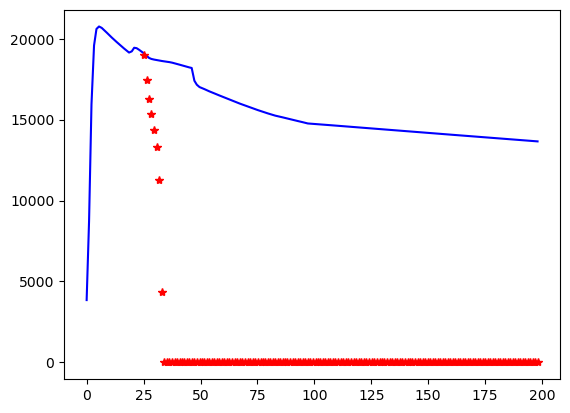

In [202]:
plt.show()

# TCN Thrust Model

In [211]:
import os
import pandas as pd

Data_dir = "Data/Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if f.endswith(".csv"):
        f_lst.append(os.path.join(Data_dir, f))

Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])
f_lst_train = [f for f in f_lst if f not in f_lst_test]

In [212]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ------------------------
# Configuration / Hyperparams
# ------------------------
DATA_DIR = "Data/Departures"
BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 1e-3
HIDDEN_SIZE = 128
DROPOUT = 0.2
MIN_JUMP = 0
MAX_JUMP = 8
DEVICE = torch.device("cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

POINT_FEATURES = [
    "Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta",
    "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos",
    "Wind_dir_sin", "Total_Weight"
]

# ------------------------
# Preprocessing (inchangé)
# ------------------------
def sample_sequence_from_df(df: pd.DataFrame, rng=np.random):
    df = df.copy()
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if ground_rows.shape[0] == 0: return None
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())
    air_df = df[df["Altitude_Above_Ground"] > 0].copy()
    air_df = air_df[air_df["Time"] > t0]
    if air_df.empty: return None
    air_df = air_df.sort_values("Time").reset_index(drop=True)
    sampled_indices = []
    current_time = t0 + rng.randint(MIN_JUMP, MAX_JUMP)
    while True:
        candidates = air_df[air_df["Time"] >= current_time]
        if candidates.empty: break
        idx = int(candidates.index[0])
        if sampled_indices and idx == sampled_indices[-1]:
            current_time += 1.0; continue
        sampled_indices.append(idx)
        current_time += rng.randint(MIN_JUMP, MAX_JUMP)
    if len(sampled_indices) == 0: return None
    sampled = air_df.loc[sampled_indices].reset_index(drop=True)
    times = sampled["Time"].values.astype(float)
    targets = sampled["Thrust"].values.astype(float)
    inputs = []
    for i in range(len(times)):
        dt = (times[i] - t0) if i == 0 else (times[i] - times[i-1])
        prev_thrust = max_ground_thrust if i == 0 else targets[i-1]
        row_feats = sampled.loc[i, POINT_FEATURES].values.astype(float)
        inputs.append(np.concatenate([row_feats, [dt, prev_thrust]]))
    return np.vstack(inputs), targets.astype(float), times.astype(float)

# ------------------------
# Dataset
# ------------------------
class FlightSequenceDataset(Dataset):
    def __init__(self, file_list, rng_seed=SEED):
        self.sequences = []
        self.rng = np.random.RandomState(rng_seed)
        for f in tqdm(file_list, desc="Preparing sequences"):
            df = pd.read_csv(f).dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
            result = sample_sequence_from_df(df, rng=self.rng)
            if result and result[0].shape[0] >= 3:
                self.sequences.append(result)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        inputs, targets, _ = self.sequences[idx]
        return {"inputs": torch.tensor(inputs, dtype=torch.float32),
                "targets": torch.tensor(targets, dtype=torch.float32),
                "length": inputs.shape[0]}

def collate_fn(batch):
    inputs = [item["inputs"] for item in batch]
    targets = [item["targets"] for item in batch]
    lengths = [int(item["length"]) for item in batch]
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0.0)
    targets_padded = pad_sequence([t.unsqueeze(1) for t in targets], batch_first=True, padding_value=0.0).squeeze(-1)
    maxT = inputs_padded.size(1)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    for i, L in enumerate(lengths): mask[i, :L] = True
    return {"inputs": inputs_padded, "targets": targets_padded, "mask": mask}

# ------------------------
# Scaler + persistence des datasets (manquait dans ta version TCN)
# ------------------------
def fit_scalers(dataset: FlightSequenceDataset):
    all_inputs = np.vstack([seq[0] for seq in dataset.sequences])
    scaler = StandardScaler()
    scaler.fit(all_inputs)
    return scaler

def save_datasets(train_ds, val_ds, path="Data/thrust_tcn_datasets.pt"):
    torch.save({"train_sequences": train_ds.sequences, "val_sequences": val_ds.sequences}, path)
    print(f"Saved datasets to {path}")

def load_datasets(path="Data/thrust_tcn_datasets.pt"):
    data = torch.load(path, map_location="cpu", weights_only=False)
    train_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    train_ds.sequences = data["train_sequences"]
    val_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    val_ds.sequences = data["val_sequences"]
    return train_ds, val_ds

# ------------------------
# TCN — version CAUSALE corrigée
# ------------------------
class Chomp1d(nn.Module):
    """Coupe les `chomp_size` derniers pas de temps produits par le padding
    symétrique de Conv1d, pour ne garder que du padding à GAUCHE -> conv causale."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x

class ThrustTCN(nn.Module):
    def __init__(self, input_dim, hidden_size=128, dropout=0.2):
        super().__init__()
        def causal_layer(in_ch, out_ch, kernel_size, dilation):
            pad = (kernel_size - 1) * dilation
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad, dilation=dilation),
                Chomp1d(pad),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
        self.layer1 = causal_layer(input_dim, hidden_size, kernel_size=3, dilation=1)
        self.layer2 = causal_layer(hidden_size, hidden_size, kernel_size=3, dilation=2)
        self.layer3 = causal_layer(hidden_size, hidden_size, kernel_size=3, dilation=4)
        self.head = nn.Conv1d(hidden_size, 1, kernel_size=1)  # projection finale, pas de padding nécessaire

    def forward(self, x):
        # x: (B, T, D) -> (B, D, T)
        x = x.permute(0, 2, 1)
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.head(out)        # (B, 1, T)
        return out.squeeze(1)       # (B, T) -- longueur garantie == T

# ------------------------
# Training / Eval
# ------------------------
def train_epoch(model, dataloader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="Training"):
        inputs, targets, mask = batch["inputs"].to(DEVICE), batch["targets"].to(DEVICE), batch["mask"].to(DEVICE)
        B, T, D = inputs.shape
        inp_scaled = torch.tensor(scaler.transform(inputs.cpu().numpy().reshape(-1, D)).reshape(B, T, D), dtype=torch.float32)
        optimizer.zero_grad()
        preds = model(inp_scaled)
        loss = ((preds - targets) * mask).pow(2).sum() / (mask.sum() + 1e-8)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * B
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, scaler):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            inputs, targets, mask = batch["inputs"].to(DEVICE), batch["targets"].to(DEVICE), batch["mask"].to(DEVICE)
            B, T, D = inputs.shape
            inp_scaled = torch.tensor(scaler.transform(inputs.cpu().numpy().reshape(-1, D)).reshape(B, T, D), dtype=torch.float32)
            preds = model(inp_scaled)
            loss = ((preds - targets) * mask).pow(2).sum() / (mask.sum() + 1e-8)
            total_loss += loss.item() * B
    return total_loss / len(dataloader.dataset)

### Create dataset

In [223]:
from joblib import dump
import os

# ------------------------
# Putting it together
# ------------------------
file_list = copy.copy(f_lst_train)
if len(file_list) == 0:
    raise RuntimeError(f"No CSV files in {DATA_DIR}")

# split train/val
random.shuffle(file_list)
n_train = int(0.8 * len(file_list))
train_files = file_list[:n_train]
val_files = file_list[n_train:]

# 2) build datasets
train_ds = FlightSequenceDataset(train_files, rng_seed=SEED)
val_ds = FlightSequenceDataset(val_files, rng_seed=SEED + 1)
save_datasets(train_ds, val_ds, path="Data/thrust_tcn_datasets.pt")

# 3) fit scaler on train set
scaler = fit_scalers(train_ds)
os.makedirs("Models/model_thrust", exist_ok=True)
dump(scaler, "Models/model_thrust/scaler_thrust_tcn.bin", compress=True)

Preparing sequences: 100%|██████████| 6661/6661 [07:01<00:00, 15.81it/s]


Saved datasets to Data/thrust_tcn_datasets.pt


['Models/model_thrust/scaler_thrust_tcn.bin']

### Train the model

In [224]:
train_ds, val_ds = load_datasets(path="Data/thrust_tcn_datasets.pt")
sample_item = train_ds[0]["inputs"]
input_dim = sample_item.shape[1]

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = ThrustTCN(input_dim=input_dim, hidden_size=HIDDEN_SIZE, dropout=DROPOUT)
model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

best_val = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scaler)
    val_loss = eval_epoch(model, val_loader, scaler)
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,
            "input_dim": input_dim,
        }, "Models/model_thrust/best_thrust_tcn.pt")
        print("  -> saved best model")

print("Training finished. Best val loss:", best_val)

Eval: 100%|██████████| 417/417 [00:02<00:00, 178.26it/s]


Epoch 01 | train_loss=12476130.486245 | val_loss=221626.560926
  -> saved best model


Eval: 100%|██████████| 417/417 [00:02<00:00, 171.90it/s]


Epoch 02 | train_loss=1396333.595706 | val_loss=107213.072525
  -> saved best model


Eval: 100%|██████████| 417/417 [00:02<00:00, 172.34it/s]


...

Epoch 28 | train_loss=1019987.166116 | val_loss=48255.954916


Eval: 100%|██████████| 417/417 [00:02<00:00, 173.58it/s]


Epoch 29 | train_loss=1020793.890857 | val_loss=37092.285313


Eval: 100%|██████████| 417/417 [00:02<00:00, 176.75it/s]

Epoch 30 | train_loss=1018437.186853 | val_loss=29564.302404
Training finished. Best val loss: 22036.21241766439


### Load Model

In [235]:
def load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt"):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    input_dim = ckpt["input_dim"]
    model = ThrustTCN(input_dim=input_dim)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    model.to(DEVICE)
    scaler = StandardScaler()
    scaler.mean_ = ckpt["scaler_mean"]
    scaler.scale_ = ckpt["scaler_scale"]
    scaler.n_features_in_ = scaler.mean_.shape[0]
    return model, scaler, input_dim

def autoregressive_predict(model, scaler, inputs):
    x_scaled = scaler.transform(inputs)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        preds = model(x_tensor)
    return preds.squeeze(0).cpu().numpy()

def run_on_flight(filepath, model, scaler):
    df = pd.read_csv(filepath)
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    seq = sample_sequence_from_df(df)
    if seq is None:
        return None
    inputs, true_thrust, times = seq
    preds = autoregressive_predict(model, scaler, inputs)
    return {"times": times, "true_thrust": true_thrust, "pred_thrust": preds, "inputs": inputs}

model, scaler, input_dim = load_thrust_model()
flight_file = f_lst_test[0]
df = pd.read_csv(flight_file)
out = run_on_flight(flight_file, model, scaler)

#========================================================
#Old Model
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")
flight_data = df[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

y_pred_scaled = model_thrust.predict(X_flight)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]
#==========================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(df["Time"], df["Thrust"], "b", label = "True Thrust")
plt.plot(out["times"], out["pred_thrust"], "r", label="TCN Prediction")
plt.plot(df['Time'], y_pred, "g", label="Old Thrust model") 
plt.xlabel("Time (s)")
plt.ylabel("Thrust")
plt.legend()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


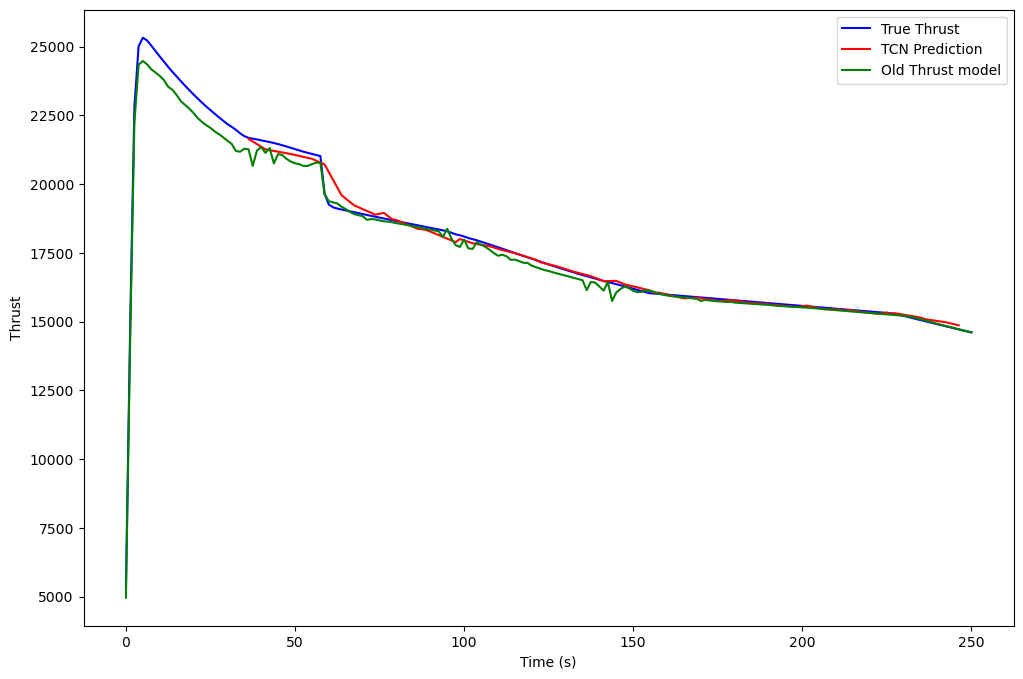

In [236]:
plt.show()

### Test on a single flight

In [237]:
def predict_thrust_from_df(df, model, scaler, device="cpu"):
    """
    df: full flight dataframe
    model: loaded ThrustTCN model
    scaler: StandardScaler reconstructed
    Returns:
        times: np.array of timestamps (airborne)
        preds: np.array of predicted thrust values
    """
    POINT_FEATURES = [
        "Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta",
        "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos",
        "Wind_dir_sin", "Total_Weight",
    ]
    
    # ---- 1) PREPARE DATAFRAME ----
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    df = df.sort_values("Time").reset_index(drop=True)

    # ---- 2) Find t0 ----
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if len(ground_rows) == 0:
        raise ValueError("No ground rows in the dataframe!")
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # ---- 3) Extract airborne rows ----
    air_df = df[(df["Altitude_Above_Ground"] > 0) & (df["Time"] > t0)].reset_index(drop=True)
    if air_df.empty:
        raise ValueError("No airborne rows found after t0.")

    times = air_df["Time"].values.astype(float)
    
    # ---- 4) Build full input sequence at once ----
    # For TCN, we need a complete sequence with dt and prev_thrust
    inputs_list = []
    prev_t = max_ground_thrust
    
    for i in range(len(times)):
        feats = air_df.loc[i, POINT_FEATURES].values.astype(float)
        dt = (times[i] - t0) if i == 0 else (times[i] - times[i-1])
        inputs_list.append(np.concatenate([feats, [dt, prev_t]]))
        # In this approach, we use true previous thrust (or model-predicted if preferred)
        prev_t = air_df.loc[i, "Thrust"] 

    full_inputs = np.vstack(inputs_list) # (T, D)

    # ---- 5) Scale and Predict ----
    x_scaled = scaler.transform(full_inputs) # Scale (T, D)
    x = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device) # (1, T, D)

    model.eval()
    with torch.no_grad():
        # TCN predicts the whole sequence in one pass
        preds = model(x).squeeze(0).cpu().numpy() # (T,)

    return times, preds

In [238]:
f_lst_test[1]

'Data\\Departures\\2024-07-26---08-27-12.csv'

In [243]:
df = pd.read_csv(f_lst_test[1])
model_thrust_tcn, scaler_thrust_tcn, input_dim = load_thrust_model(path="Models/model_thrust/best_thrust_tcn.pt")
times, pred_thrust = predict_thrust_from_df(df, model_thrust_tcn, scaler_thrust_tcn)

print(times)
print(pred_thrust)

[ 25.25    26.3125  27.375   28.4375  29.625   30.6875  31.8125  33.
  34.0625  35.3125  36.375   37.5625  38.6875  39.75    40.8125  41.875
  42.9375  44.      45.0625  46.125   47.3125  48.375   49.5625  50.6875
  51.75    52.8125  53.875   55.      56.0625  57.125   58.1875  59.3125
  60.5     61.625   62.6875  63.8125  65.      66.125   67.25    68.4375
  69.625   70.6875  71.8125  73.      74.0625  75.125   76.375   77.4375
  78.5     79.5625  80.625   81.75    82.8125  83.9375  85.      86.0625
  87.125   88.1875  89.375   90.4375  91.5     92.625   93.6875  94.8125
  95.875   97.125   98.25    99.4375 100.5    101.5625 102.6875 103.75
 104.8125 105.875  106.9375 108.     109.25   110.4375 111.5    112.6875
 113.8125 114.9375 116.125  117.3125 118.375  119.4375 120.5625 121.75
 122.8125 124.0625 125.25   126.3125 127.4375 128.625  129.6875 130.75
 131.9375 133.     134.0625 135.25   136.4375 137.625  138.6875 139.875
 140.9375 142.     143.0625 144.1875 145.375  146.5    147.5625

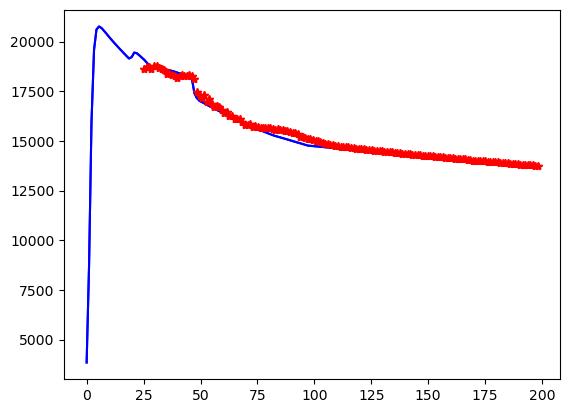

In [245]:
plt.plot(df["Time"],df["Thrust"], "b")
plt.plot(times, pred_thrust, "*r")
plt.show()